## LSTM Model for Sepsis Prediction

This notebook implements an LSTM neural network for early prediction of sepsis using ICU time-series data.

The workflow includes:
- data preprocessing and missing value imputation (MICE),
- creation of 24-hour patient sequences,
- feature scaling,
- training an LSTM model with class weighting and early stopping,
- evaluation using ROC-AUC

In [1]:
# Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

## Random Seed

In [2]:
tf.keras.utils.set_random_seed(42)

## Data preparation

In [3]:
def prep_sequences_by_patient_mice(
    df,
    pid_col='patient_ID',
    time_col='ICULOS',
    label='SepsisLabel',
    seq_len=24,
    test_size=0.2,
    val_size=0.2,
    random_state=42
):

    patient_label = df.groupby(pid_col)[label].max()

    temp_size = test_size + val_size

    train_ids, temp_ids = train_test_split(
        patient_label.index,
        test_size=temp_size,
        stratify=patient_label,
        random_state=random_state
    )

    temp_pl = patient_label.loc[temp_ids]

    val_prop = val_size / (val_size + test_size)

    val_ids, test_ids = train_test_split(
        temp_pl.index,
        test_size=1 - val_prop,
        stratify=temp_pl,
        random_state=random_state
    )

    train_df = df[df[pid_col].isin(train_ids)].copy()
    val_df = df[df[pid_col].isin(val_ids)].copy()
    test_df = df[df[pid_col].isin(test_ids)].copy()

    mask_cols = [c for c in MASK_COLS if c in df.columns]

    def make_masks(_d):
        if mask_cols:
            return _d[mask_cols].isna().astype("int8").add_suffix("_is_missing")
        else:
            return pd.DataFrame(index=_d.index)

    tr_mask = make_masks(train_df)
    va_mask = make_masks(val_df)
    te_mask = make_masks(test_df)

    cols_to_impute = [c for c in (MASK_COLS + MICE_ONLY) if c in df.columns]

    if cols_to_impute:

        imp = IterativeImputer(
            random_state=random_state,
            max_iter=20,
            sample_posterior=True,
            initial_strategy="median"
        )

        tr_imp = pd.DataFrame(
            imp.fit_transform(train_df[cols_to_impute]),
            columns=cols_to_impute,
            index=train_df.index
        )

        va_imp = pd.DataFrame(
            imp.transform(val_df[cols_to_impute]),
            columns=cols_to_impute,
            index=val_df.index
        )

        te_imp = pd.DataFrame(
            imp.transform(test_df[cols_to_impute]),
            columns=cols_to_impute,
            index=test_df.index
        )

        train_df = pd.concat([train_df.drop(columns=cols_to_impute), tr_imp, tr_mask], axis=1)
        val_df = pd.concat([val_df.drop(columns=cols_to_impute), va_imp, va_mask], axis=1)
        test_df = pd.concat([test_df.drop(columns=cols_to_impute), te_imp, te_mask], axis=1)

    else:

        train_df = pd.concat([train_df, tr_mask], axis=1)
        val_df = pd.concat([val_df, va_mask], axis=1)
        test_df = pd.concat([test_df, te_mask], axis=1)

    drop_cols = {label, pid_col, time_col}

    feat_cols = [
        c for c in train_df.columns
        if c not in drop_cols and pd.api.types.is_numeric_dtype(train_df[c])
    ]

    val_df = val_df.reindex(columns=train_df.columns)
    test_df = test_df.reindex(columns=train_df.columns)

    def make_windows(df_part):

        X_list, y_list = [], []

        for pid, g in df_part.groupby(pid_col):

            g = g.sort_values(time_col)

            if len(g) < seq_len:
                continue

            feats = g[feat_cols].to_numpy(dtype=np.float32)
            ys = g[label].to_numpy(dtype=np.int32)

            for end in range(seq_len - 1, len(g)):
                X_list.append(feats[end-seq_len+1:end+1])
                y_list.append(ys[end])

        return np.array(X_list), np.array(y_list)

    X_tr, y_tr = make_windows(train_df)
    X_va, y_va = make_windows(val_df)
    X_te, y_te = make_windows(test_df)

    scaler = StandardScaler()

    X_tr = scaler.fit_transform(X_tr.reshape(-1, X_tr.shape[-1])).reshape(X_tr.shape)
    X_va = scaler.transform(X_va.reshape(-1, X_va.shape[-1])).reshape(X_va.shape)
    X_te = scaler.transform(X_te.reshape(-1, X_te.shape[-1])).reshape(X_te.shape)

    return X_tr, X_va, X_te, y_tr, y_va, y_te

## Upload data

In [4]:
# import preprocessed data frame 
df = pd.read_csv('df_model_imputed.csv')

MASK_COLS = ['EtCO2','FiO2','PaCO2','pH','BaseExcess','Potassium'] 
MICE_ONLY = ['Glucose','Hct','Hgb','BUN','Magnesium','Creatinine','WBC','Calcium', 'Platelets']

In [5]:
X_tr, X_va, X_te, y_tr, y_va, y_te = prep_sequences_by_patient_mice(df)
print(X_tr.shape, X_va.shape, X_te.shape)

(341059, 24, 38) (114816, 24, 38) (115596, 24, 38)


## LSTM Model Definition

In [6]:
def fit_lstm(X_train, y_train, X_val, y_val, X_test, y_test):

    cw = compute_class_weight(
        class_weight="balanced",
        classes=np.array([0,1]),
        y=y_train
    )

    class_weights = {0: cw[0], 1: cw[1]}

    inp = tf.keras.layers.Input(shape=(X_train.shape[1], X_train.shape[2]))

    x = tf.keras.layers.LSTM(64, return_sequences=True)(inp)
    x = tf.keras.layers.Dropout(0.30)(x)

    x = tf.keras.layers.LSTM(32)(x)
    x = tf.keras.layers.Dropout(0.20)(x)

    out = tf.keras.layers.Dense(1, activation="sigmoid")(x)

    model = tf.keras.Model(inp, out)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.0003),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        patience=8,
        restore_best_weights=True
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=60,
        batch_size=64,
        class_weight=class_weights,
        callbacks=[early_stop]
    )

    y_proba = model.predict(X_test).ravel()

    return model, y_proba, history

## Model Training

In [7]:
model_lstm, y_proba_lstm, history = fit_lstm(
    X_tr, y_tr,
    X_va, y_va,
    X_te, y_te
)


Epoch 1/60


5330/5330 [==============================] - 133s 24ms/step - loss: 0.4582 - accuracy: 0.7651 - auc: 0.8633 - val_loss: 0.4327 - val_accuracy: 0.7764 - val_auc: 0.8469
Epoch 2/60
5330/5330 [==============================] - 137s 26ms/step - loss: 0.3613 - accuracy: 0.8009 - auc: 0.9127 - val_loss: 0.3612 - val_accuracy: 0.8290 - val_auc: 0.8361
Epoch 3/60
5330/5330 [==============================] - 141s 26ms/step - loss: 0.2938 - accuracy: 0.8364 - auc: 0.9390 - val_loss: 0.3414 - val_accuracy: 0.8428 - val_auc: 0.8103
Epoch 4/60
5330/5330 [==============================] - 140s 26ms/step - loss: 0.2455 - accuracy: 0.8644 - auc: 0.9547 - val_loss: 0.3653 - val_accuracy: 0.8455 - val_auc: 0.8015
Epoch 5/60
5330/5330 [==============================] - 137s 26ms/step - loss: 0.2147 - accuracy: 0.8821 - auc: 0.9635 - val_loss: 0.3147 - val_accuracy: 0.8739 - val_auc: 0.7938
Epoch 6/60
5330/5330 [==============================] - 138s 26ms/step - loss: 0.1882 - accuracy: 0.89

## Model Evaluation

In [8]:
threshold = 0.45

y_pred = (y_proba_lstm >= threshold).astype(int)

print("ROC-AUC:", roc_auc_score(y_te, y_proba_lstm))
print("PR-AUC:", average_precision_score(y_te, y_proba_lstm))
print("Recall:", recall_score(y_te, y_pred))
print("Precision:", precision_score(y_te, y_pred))
print("F1:", f1_score(y_te, y_pred))

print("\nConfusion matrix")
print(confusion_matrix(y_te, y_pred))

ROC-AUC: 0.8211472469723178
PR-AUC: 0.1264487770365493
Recall: 0.7527454242928453
Precision: 0.07301249152706497
F1: 0.13311363502618725

Confusion matrix
[[83872 28719]
 [  743  2262]]


## ROC functions

In [11]:
from sklearn.metrics import roc_curve, auc

def plot_roc(model_names, y_proba_list, y_test):

    plt.figure(figsize=(10,8))

    colors = ['darkred','darkblue','darkgreen']

    for i,(model_name,y_proba) in enumerate(zip(model_names,y_proba_list)):

        fpr,tpr,_ = roc_curve(y_test,y_proba)
        roc_auc = auc(fpr,tpr)

        plt.plot(
            fpr,
            tpr,
            lw=2,
            color=colors[i],
            label=f'{model_name} (AUC = {roc_auc:.3f})'
        )

    plt.plot([0,1],[0,1],'--',color='gray')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title("ROC Curve Comparison")

    plt.legend(loc="lower right")

    plt.grid(True)

    plt.show()

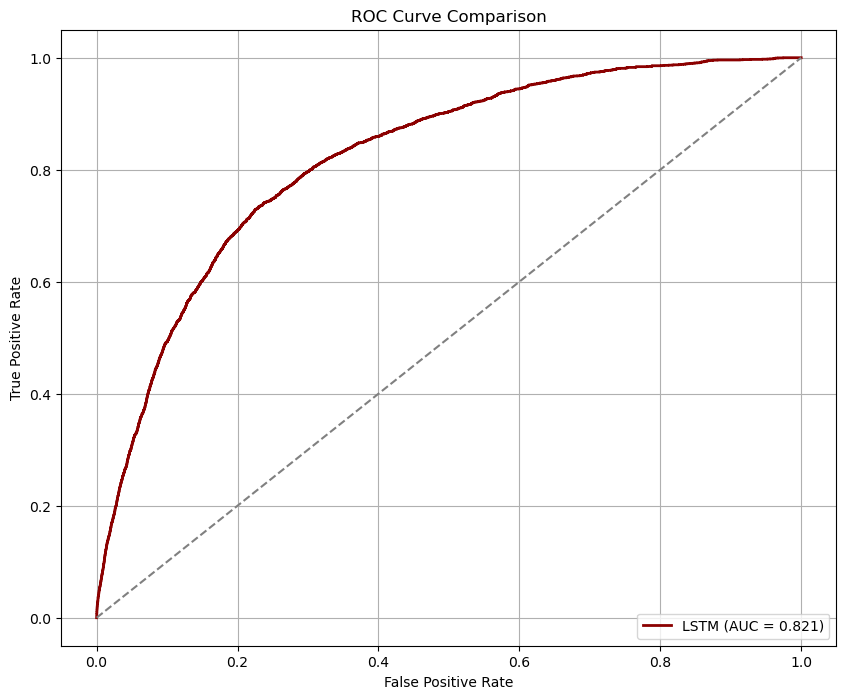

In [14]:
# ROC for LSTM 
plot_roc(['LSTM'], [y_proba_lstm], y_te)

## Training Visualization

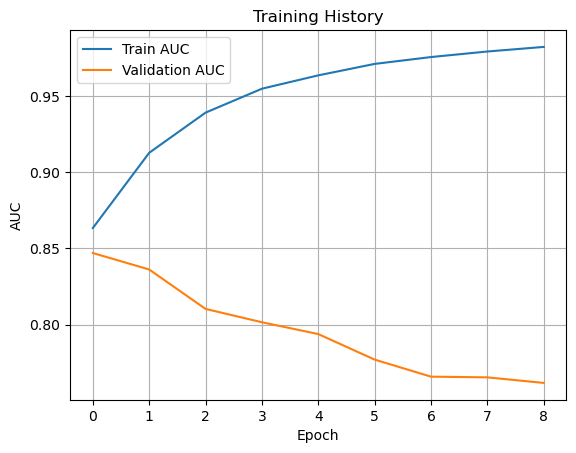

In [15]:
plt.plot(history.history["auc"], label="Train AUC")
plt.plot(history.history["val_auc"], label="Validation AUC")

plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Training History")

plt.legend()
plt.grid()

plt.show()

The training AUC increases steadily while the validation AUC decreases after the first epochs, indicating mild overfitting. 
This behaviour is common for deep learning models trained on relatively small clinical datasets. 
Early stopping is used to restore the model weights from the best validation epoch.